<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_hipotesis4_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Celda 1: Importación, Carga, Limpieza e Ingeniería de Características
# =============================================================================
# Este bloque de código realiza todas las tareas de preparación de datos,
# desde la importación de librerías hasta la creación de características
# de ingeniería (rezagos e indicadores técnicos) para validar la Hipótesis 4.

# 1.1. Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Configuraciones visuales para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print("Librerías importadas y configuración lista.")

# 1.2. Carga de Datos
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no se encontró.")
    raise

# 1.3. Limpieza y Preparación Inicial
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 1.4. Corrección de Lookahead Bias y Creación de Variable Objetivo
# Se calcula el retorno y se desplaza para que el objetivo del día 't' sea el retorno del día 't+1'
df['GOOGL_Return'] = df['GOOGL_Close'].pct_change()
df['AMZN_Return'] = df['AMZN_Close'].pct_change()
df['GOOGL_Target_Return'] = df['GOOGL_Return'].shift(-1)
df['AMZN_Target_Return'] = df['AMZN_Return'].shift(-1)

# Eliminar columnas que no se usarán o causarían fuga de datos
df = df.drop(columns=['GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Return', 'AMZN_Return'])

# 1.5. Ingeniería de Características para Validar H4
print("\nIniciando Ingeniería de Características...")

# Definimos los horizontes temporales para los rezagos y medias móviles
horizontes = [5, 10, 20, 60] # Días hábiles (aprox. 1 semana, 2 semanas, 1 mes, 3 meses)

# Iterar sobre cada activo para crear sus características específicas
for asset in ['GOOGL', 'AMZN']:
    # 1.5.1. Creación de Retornos Rezagados (Lags)
    # Se utiliza el retorno DIARIO (calculado con pct_change) para los rezagos.
    # Primero calculamos el retorno diario sobre el precio de cierre.
    daily_return = df[f'{asset}_Close'].pct_change()
    for lag in horizontes:
        # El lag de retorno es el retorno de hace 'n' días.
        df[f'{asset}_Return_Lag_{lag}'] = daily_return.shift(lag)

    # 1.5.2. Creación de Medias Móviles Simples (SMA) del Precio de Cierre
    for window in horizontes:
        df[f'{asset}_SMA_{window}'] = df[f'{asset}_Close'].rolling(window=window).mean()

    # 1.5.3. Creación de Indicador de Momentum (RSI - Índice de Fuerza Relativa)
    delta = df[f'{asset}_Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df[f'{asset}_RSI_14'] = 100 - (100 / (1 + rs))

# 1.6. Limpieza Final
# Eliminar filas con valores NaN generados por los cálculos de rolling y shift
df.dropna(inplace=True)

print("Ingeniería de características completada.")
print("Dimensiones finales del DataFrame:", df.shape)

# Separar en dos DataFrames para el análisis: uno base y uno con ingeniería
# DataFrame Base (sin las nuevas características históricas)
base_features = [col for col in df.columns if not any(x in col for x in ['_Lag_', '_SMA_', '_RSI_'])]
df_base = df[base_features].copy()

# DataFrame con Ingeniería
df_engineered = df.copy()

print("\nDataFrames listos para el modelado:")
print(f"  - df_base: {df_base.shape[1]} columnas")
print(f"  - df_engineered: {df_engineered.shape[1]} columnas")

# Mostrar las primeras filas del DataFrame enriquecido
df_engineered.head()

Librerías importadas y configuración lista.
Dataset cargado exitosamente.

Iniciando Ingeniería de Características...
Ingeniería de características completada.
Dimensiones finales del DataFrame: (935, 29)

DataFrames listos para el modelado:
  - df_base: 11 columnas
  - df_engineered: 29 columnas


,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE,GOOGL_Target_Return,...,GOOGL_RSI_14,AMZN_Return_Lag_5,AMZN_Return_Lag_10,AMZN_Return_Lag_20,AMZN_Return_Lag_60,AMZN_SMA_5,AMZN_SMA_10,AMZN_SMA_20,AMZN_SMA_60,AMZN_RSI_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,105.982300,158.050003,1.679,17.330000,4019.870117,13480.110352,1.555290,2.403688,2.55,0.041873,...,66.754848,-0.013220,-0.034359,-0.009128,0.010004,154.381299,154.473950,153.770076,158.450459,56.797919
2021-04-05,110.420082,161.336502,1.720,17.910000,4077.909912,13705.589844,2.383186,2.777608,2.55,-0.004371,...,75.481688,0.001894,0.015512,0.007687,-0.024897,156.128299,155.232800,154.335751,158.524083,62.421013
2021-04-06,109.937386,161.190994,1.656,18.120001,4073.939941,13698.379883,2.835656,2.704171,2.52,0.013475,...,70.683314,0.007765,0.011678,-0.016167,0.007577,157.609198,155.797549,155.015426,158.575467,61.442533
2021-04-07,111.418816,163.969498,1.653,17.160000,4079.949951,13688.839844,3.386650,3.322528,2.53,0.005092,...,73.675134,-0.006646,0.008560,0.037568,0.006496,159.850198,156.506999,155.556776,158.656042,62.209339
2021-04-08,111.986107,164.964996,1.632,16.950001,4097.169922,13829.309570,3.846033,3.864854,2.55,0.008994,...,90.663479,0.012696,-0.016073,-0.001701,-0.021519,161.902399,157.568149,156.160925,158.810283,77.104413


In [3]:
# Celda 2: División de Datos para Ambos Escenarios
# =============================================================================

# --- Escenario 1: Modelo Base (sin ingeniería de características) ---
features_base = [col for col in df_base.columns if 'Target' not in col]
X_base = df_base[features_base]
y_googl_base = df_base['GOOGL_Target_Return']
y_amzn_base = df_base['AMZN_Target_Return']

split_index_base = int(len(df_base) * 0.8)
X_train_base, X_test_base = X_base[:split_index_base], X_base[split_index_base:]
y_train_googl_base, y_test_googl_base = y_googl_base[:split_index_base], y_googl_base[split_index_base:]
y_train_amzn_base, y_test_amzn_base = y_amzn_base[:split_index_base], y_amzn_base[split_index_base:]

# --- Escenario 2: Modelo con Ingeniería de Características ---
features_eng = [col for col in df_engineered.columns if 'Target' not in col]
X_eng = df_engineered[features_eng]
y_googl_eng = df_engineered['GOOGL_Target_Return']
y_amzn_eng = df_engineered['AMZN_Target_Return']

split_index_eng = int(len(df_engineered) * 0.8)
X_train_eng, X_test_eng = X_eng[:split_index_eng], X_eng[split_index_eng:]
y_train_googl_eng, y_test_googl_eng = y_googl_eng[:split_index_eng], y_googl_eng[split_index_eng:]
y_train_amzn_eng, y_test_amzn_eng = y_amzn_eng[:split_index_eng], y_amzn_eng[split_index_eng:]

print("División de datos para ambos escenarios (Base y con Ingeniería) completada.")

División de datos para ambos escenarios (Base y con Ingeniería) completada.


--- Validación de Hipótesis H4 para GOOGLE ---

Comparación de rendimiento para GOOGLE:
  MSE Modelo Base: 0.00070382
  MSE Modelo con Históricos: 0.00215678
  Mejora en Precisión (Reducción de MSE): -206.44%
Conclusión: Hipótesis 4 no validada para GOOGLE.


/tmp/ipython-input-4-2865382152.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_googl_eng.head(20), palette='rocket')


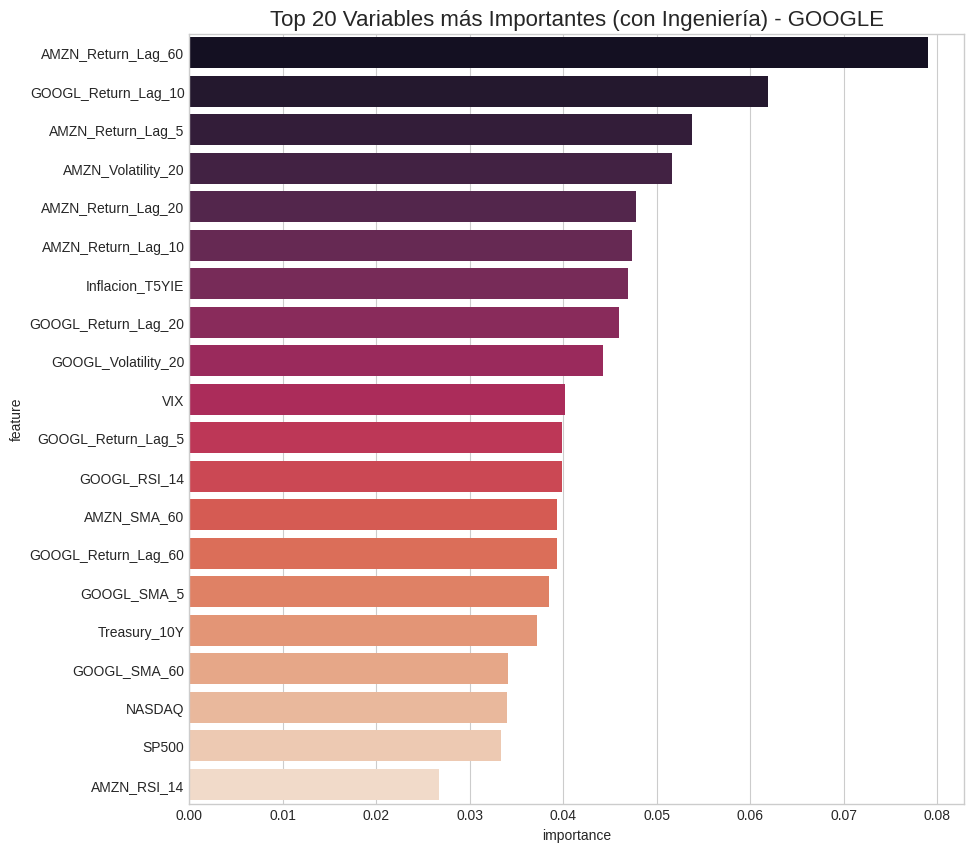

In [4]:
# Celda 3: Validación de Hipótesis H4 para GOOGLE
# =============================================================================

print("--- Validación de Hipótesis H4 para GOOGLE ---")

# Entrenar Modelo Base
rf_model_googl_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_googl_base.fit(X_train_base, y_train_googl_base)
y_pred_googl_base = rf_model_googl_base.predict(X_test_base)
mse_googl_base = mean_squared_error(y_test_googl_base, y_pred_googl_base)

# Entrenar Modelo con Ingeniería
rf_model_googl_eng = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_googl_eng.fit(X_train_eng, y_train_googl_eng)
y_pred_googl_eng = rf_model_googl_eng.predict(X_test_eng)
mse_googl_eng = mean_squared_error(y_test_googl_eng, y_pred_googl_eng)

# Comparación y Cuantificación de la Mejora
print("\nComparación de rendimiento para GOOGLE:")
print(f"  MSE Modelo Base: {mse_googl_base:.8f}")
print(f"  MSE Modelo con Históricos: {mse_googl_eng:.8f}")
mejora_mse_googl = ((mse_googl_base - mse_googl_eng) / mse_googl_base) * 100
print(f"  Mejora en Precisión (Reducción de MSE): {mejora_mse_googl:.2f}%")

if mejora_mse_googl > 0:
    print("Conclusión: Hipótesis 4 validada para GOOGLE.")
else:
    print("Conclusión: Hipótesis 4 no validada para GOOGLE.")

# Análisis de Importancia de las nuevas variables
feature_importances_googl_eng = pd.DataFrame({
    'feature': features_eng,
    'importance': rf_model_googl_eng.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_googl_eng.head(20), palette='rocket')
plt.title('Top 20 Variables más Importantes (con Ingeniería) - GOOGLE', fontsize=16)
plt.show()

--- Validación de Hipótesis H4 para AMAZON ---

Comparación de rendimiento para AMAZON:
  MSE Modelo Base: 0.00053643
  MSE Modelo con Históricos: 0.00139018
  Mejora en Precisión (Reducción de MSE): -159.16%
Conclusión: Hipótesis 4 no validada para AMAZON.


/tmp/ipython-input-5-4040614772.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_amzn_eng.head(20), palette='mako')


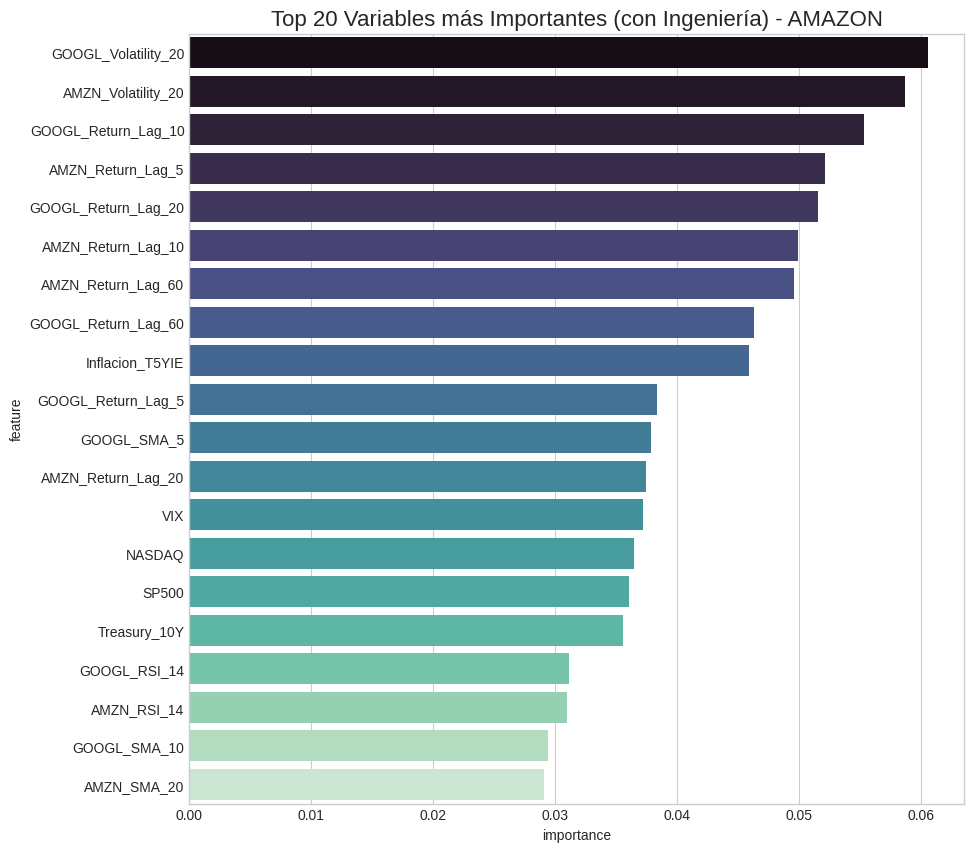

In [5]:
# Celda 4: Validación de Hipótesis H4 para AMAZON
# =============================================================================

print("--- Validación de Hipótesis H4 para AMAZON ---")

# Entrenar Modelo Base
rf_model_amzn_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_amzn_base.fit(X_train_base, y_train_amzn_base)
y_pred_amzn_base = rf_model_amzn_base.predict(X_test_base)
mse_amzn_base = mean_squared_error(y_test_amzn_base, y_pred_amzn_base)

# Entrenar Modelo con Ingeniería
rf_model_amzn_eng = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_amzn_eng.fit(X_train_eng, y_train_amzn_eng)
y_pred_amzn_eng = rf_model_amzn_eng.predict(X_test_eng)
mse_amzn_eng = mean_squared_error(y_test_amzn_eng, y_pred_amzn_eng)

# Comparación y Cuantificación de la Mejora
print("\nComparación de rendimiento para AMAZON:")
print(f"  MSE Modelo Base: {mse_amzn_base:.8f}")
print(f"  MSE Modelo con Históricos: {mse_amzn_eng:.8f}")
mejora_mse_amzn = ((mse_amzn_base - mse_amzn_eng) / mse_amzn_base) * 100
print(f"  Mejora en Precisión (Reducción de MSE): {mejora_mse_amzn:.2f}%")

if mejora_mse_amzn > 0:
    print("Conclusión: Hipótesis 4 validada para AMAZON.")
else:
    print("Conclusión: Hipótesis 4 no validada para AMAZON.")

# Análisis de Importancia de las nuevas variables
feature_importances_amzn_eng = pd.DataFrame({
    'feature': features_eng,
    'importance': rf_model_amzn_eng.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_amzn_eng.head(20), palette='mako')
plt.title('Top 20 Variables más Importantes (con Ingeniería) - AMAZON', fontsize=16)
plt.show()

In [7]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.9 MB/s eta 0:00:00


In [10]:
# Celda 1: Importación Adicional y Preparación
# =============================================================================
# Asumimos que las celdas de carga y preparación de datos ya se ejecutaron.
# importamos la librería para Gradient Boosting.

# !pip install xgboost
from xgboost import XGBRegressor

print("Librería XGBoost importada. Listos para el modelado avanzado.")

Librería XGBoost importada. Listos para el modelado avanzado.


In [11]:
# Celda 2: Entrenamiento de Modelos Supervisados (RF y XGBoost)
# =============================================================================

print("--- Entrenando modelos de Aprendizaje Supervisado ---")

# --- GOOGLE ---
# Modelo 1: Random Forest (ya entrenado, pero lo definimos aquí por claridad)
rf_model_googl_eng = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_googl_eng.fit(X_train_eng, y_train_googl_eng)
print("Modelo Random Forest para GOOGLE entrenado.")

# Modelo 2: Gradient Boosting (XGBoost)
xgb_model_googl_eng = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, objective='reg:squarederror')
xgb_model_googl_eng.fit(X_train_eng, y_train_googl_eng)
print("Modelo Gradient Boosting para GOOGLE entrenado.")

# --- AMAZON ---
# Modelo 1: Random Forest
rf_model_amzn_eng = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_amzn_eng.fit(X_train_eng, y_train_amzn_eng)
print("Modelo Random Forest para AMAZON entrenado.")

# Modelo 2: Gradient Boosting (XGBoost)
xgb_model_amzn_eng = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, objective='reg:squarederror')
xgb_model_amzn_eng.fit(X_train_eng, y_train_amzn_eng)
print("Modelo Gradient Boosting para AMAZON entrenado.")

--- Entrenando modelos de Aprendizaje Supervisado ---
Modelo Random Forest para GOOGLE entrenado.
Modelo Gradient Boosting para GOOGLE entrenado.
Modelo Random Forest para AMAZON entrenado.
Modelo Gradient Boosting para AMAZON entrenado.


In [12]:
# Celda 3: Generación de Pronósticos y Análisis de Escenarios
# =============================================================================

print("--- Definiendo Escenarios y Generando Pronósticos para 2025 ---")
future_dates = pd.date_range(start='2025-01-01', end='2025-03-31', freq='B')

# 3.1. Definición de Escenarios
scenarios = {
    'Base': {
        'Treasury_10Y': (X_eng.iloc[-1]['Treasury_10Y'], 3.8), # Ligera baja
        'VIX': 15.0,
        'Inflacion_T5YIE': 2.1,
        'SP500_growth': 1.02,
        'NASDAQ_growth': 1.03
    },
    'Optimista': {
        'Treasury_10Y': (X_eng.iloc[-1]['Treasury_10Y'], 3.5), # Caída más rápida de tasas
        'VIX': 12.0, # Baja volatilidad
        'Inflacion_T5YIE': 2.0, # Inflación controlada
        'SP500_growth': 1.05,
        'NASDAQ_growth': 1.06
    },
    'Pesimista': {
        'Treasury_10Y': (X_eng.iloc[-1]['Treasury_10Y'], 4.2), # Tasas se mantienen altas
        'VIX': 25.0, # Alta volatilidad
        'Inflacion_T5YIE': 2.8, # Inflación persistente
        'SP500_growth': 0.98,
        'NASDAQ_growth': 0.97
    }
}

def create_future_df(scenario_params, dates):
    future_df = pd.DataFrame(index=dates)
    future_df['Treasury_10Y'] = np.linspace(start=scenario_params['Treasury_10Y'][0], stop=scenario_params['Treasury_10Y'][1], num=len(dates))
    future_df['VIX'] = scenario_params['VIX']
    future_df['SP500'] = np.linspace(start=X_eng.iloc[-1]['SP500'], stop=X_eng.iloc[-1]['SP500'] * scenario_params['SP500_growth'], num=len(dates))
    future_df['NASDAQ'] = np.linspace(start=X_eng.iloc[-1]['NASDAQ'], stop=X_eng.iloc[-1]['NASDAQ'] * scenario_params['NASDAQ_growth'], num=len(dates))
    future_df['Inflacion_T5YIE'] = scenario_params['Inflacion_T5YIE']
    return future_df

# 3.2. Función de Pronóstico Iterativo (modificada para aceptar cualquier modelo)
def iterative_forecast_scenario(model, history_df, future_df, asset_name, horizons):
    # (Esta es la misma función de la celda 6 de la respuesta anterior, la incluimos aquí para que la celda sea autocontenida)
    history = history_df.copy()
    predictions = []
    last_known_price = history[f'{asset_name}_Close'].iloc[-1]
    all_features = [col for col in history.columns if 'Target' not in col]

    for i in range(len(future_df)):
        last_features_values = history[all_features].iloc[-1].values.reshape(1, -1)
        predicted_return = model.predict(last_features_values)[0]
        predicted_price = last_known_price * (1 + predicted_return)
        predictions.append(predicted_price)

        new_date = future_df.index[i]
        new_row_data = future_df.loc[new_date].to_dict()
        new_row_data[f'{asset_name}_Close'] = predicted_price

        # Llenar NaNs para el otro activo para mantener la estructura del df
        other_asset = 'AMZN' if asset_name == 'GOOGL' else 'GOOGL'
        new_row_data[f'{other_asset}_Close'] = np.nan

        new_row_df = pd.DataFrame(new_row_data, index=[new_date])
        history = pd.concat([history, new_row_df])

        daily_return = history[f'{asset_name}_Close'].pct_change()
        for lag in horizons: history.loc[new_date, f'{asset_name}_Return_Lag_{lag}'] = daily_return.shift(lag).iloc[-1]
        for window in horizons: history.loc[new_date, f'{asset_name}_SMA_{window}'] = history[f'{asset_name}_Close'].rolling(window=window).mean().iloc[-1]

        delta = history[f'{asset_name}_Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean().iloc[-1]
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean().iloc[-1]
        rs = gain / loss if loss != 0 else np.inf
        history.loc[new_date, f'{asset_name}_RSI_14'] = 100 - (100 / (1 + rs))

        last_known_price = predicted_price

    return pd.Series(predictions, index=future_df.index)

# 3.3. Generar pronósticos para cada escenario y modelo
forecasts_googl = {}
forecasts_amzn = {}

for scenario_name, params in scenarios.items():
    print(f"\nGenerando pronósticos para el escenario: {scenario_name}")
    future_df_scen = create_future_df(params, future_dates)

    # GOOGLE
    forecasts_googl[scenario_name] = {
        'RF': iterative_forecast_scenario(rf_model_googl_eng, df_engineered, future_df_scen, 'GOOGL', horizontes),
        'XGB': iterative_forecast_scenario(xgb_model_googl_eng, df_engineered, future_df_scen, 'GOOGL', horizontes)
    }
    # AMAZON
    forecasts_amzn[scenario_name] = {
        'RF': iterative_forecast_scenario(rf_model_amzn_eng, df_engineered, future_df_scen, 'AMZN', horizontes),
        'XGB': iterative_forecast_scenario(xgb_model_amzn_eng, df_engineered, future_df_scen, 'AMZN', horizontes)
    }

print("\nTodos los pronósticos de escenarios han sido generados.")

--- Definiendo Escenarios y Generando Pronósticos para 2025 ---

Generando pronósticos para el escenario: Base

Generando pronósticos para el escenario: Optimista

Generando pronósticos para el escenario: Pesimista

Todos los pronósticos de escenarios han sido generados.


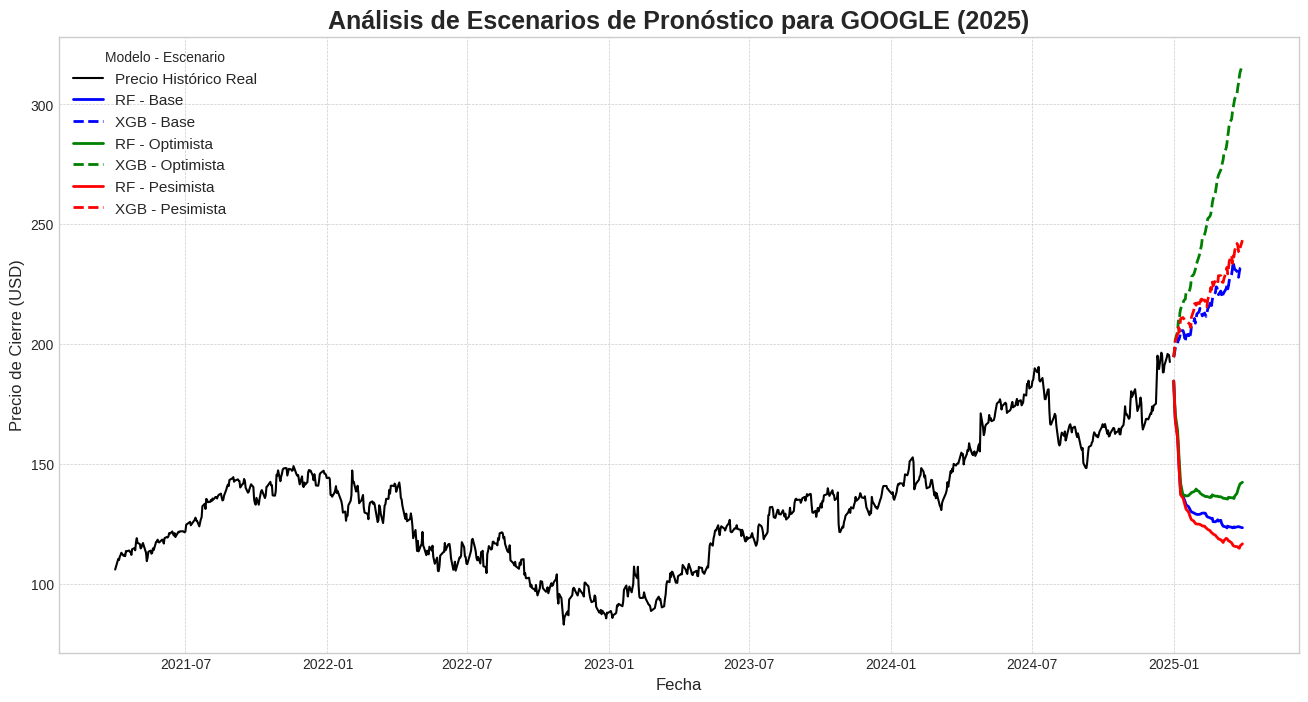

In [13]:
# Celda 4: Visualización de Escenarios - GOOGLE
# =============================================================================

plt.figure(figsize=(16, 8))

# Datos Históricos
plt.plot(df_engineered['GOOGL_Close'], label='Precio Histórico Real', color='black', linewidth=1.5)

# Colores para los escenarios
colors = {'Base': 'blue', 'Optimista': 'green', 'Pesimista': 'red'}
linestyles = {'RF': '-', 'XGB': '--'}

for scenario, models in forecasts_googl.items():
    for model_name, forecast in models.items():
        plt.plot(forecast, label=f'{model_name} - {scenario}', color=colors[scenario], linestyle=linestyles[model_name], linewidth=2)

plt.title('Análisis de Escenarios de Pronóstico para GOOGLE (2025)', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.legend(title='Modelo - Escenario', fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

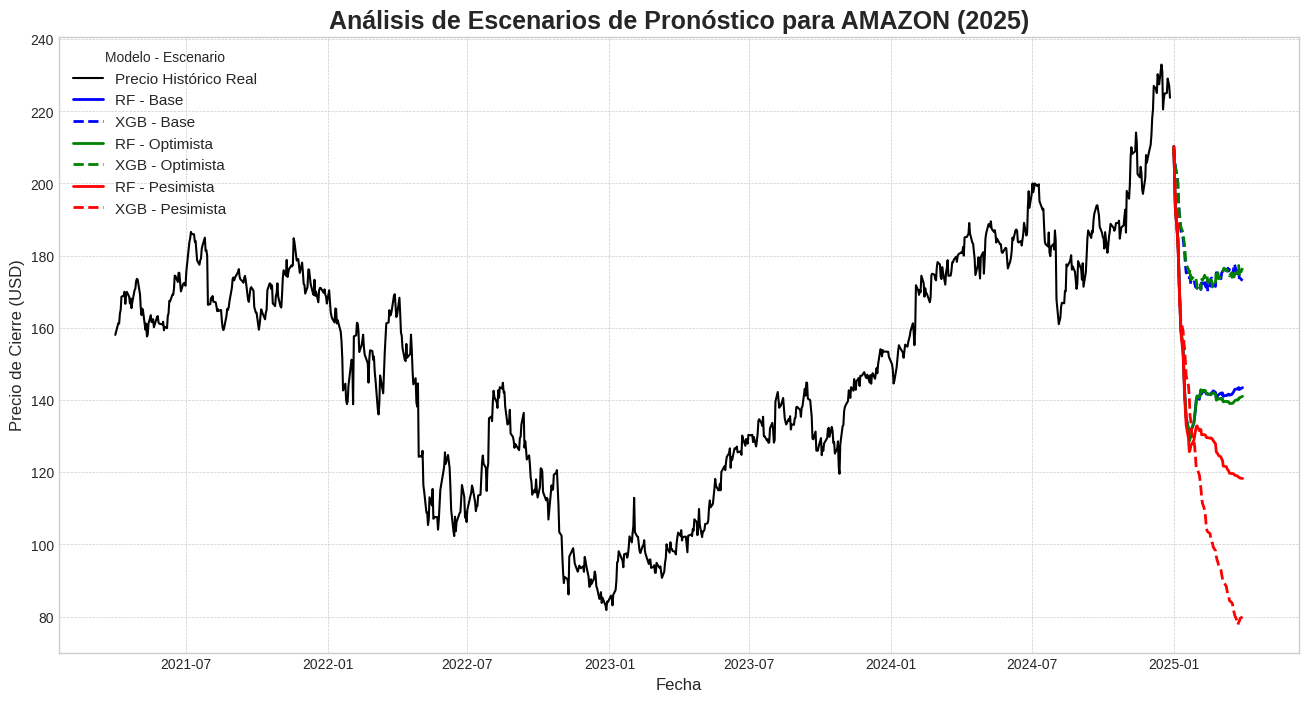

In [14]:
# Celda 5: Visualización de Escenarios - AMAZON
# =============================================================================

plt.figure(figsize=(16, 8))

# Datos Históricos
plt.plot(df_engineered['AMZN_Close'], label='Precio Histórico Real', color='black', linewidth=1.5)

# Colores y estilos
colors = {'Base': 'blue', 'Optimista': 'green', 'Pesimista': 'red'}
linestyles = {'RF': '-', 'XGB': '--'}

for scenario, models in forecasts_amzn.items():
    for model_name, forecast in models.items():
        plt.plot(forecast, label=f'{model_name} - {scenario}', color=colors[scenario], linestyle=linestyles[model_name], linewidth=2)

plt.title('Análisis de Escenarios de Pronóstico para AMAZON (2025)', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.legend(title='Modelo - Escenario', fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [15]:
# Celda 6: Creación y Visualización de Tablas de Pronósticos
# =============================================================================
# Esta celda tomará los diccionarios de pronósticos 'forecasts_googl' y 'forecasts_amzn'
# y los formateará en tablas legibles para su inclusión en la tesis.

def create_forecast_table(forecast_dict, asset_name):
    """
    Crea una tabla formateada a partir del diccionario de pronósticos.
    """
    # Seleccionar puntos clave en el tiempo para la tabla
    dates_to_show = [
        forecast_dict['Base']['RF'].index[0],  # Inicio del período (Enero 1)
        forecast_dict['Base']['RF'].index[len(forecast_dict['Base']['RF']) // 2], # Mitad del período
        forecast_dict['Base']['RF'].index[-1]  # Fin del período (Marzo 31)
    ]

    # Crear un DataFrame vacío para la tabla
    table_data = []

    last_historical_price = df_engineered[f'{asset_name}_Close'].iloc[-1]

    for scenario, models in forecast_dict.items():
        for model_name, forecast in models.items():
            for date in dates_to_show:
                forecasted_price = forecast.loc[date]
                change_pct = ((forecasted_price - last_historical_price) / last_historical_price) * 100

                table_data.append({
                    'Escenario': scenario,
                    'Modelo': model_name,
                    'Fecha de Pronóstico': date.strftime('%Y-%m-%d'),
                    'Precio Pronosticado (USD)': f"${forecasted_price:,.2f}",
                    'Cambio % vs. Fin de 2024': f"{change_pct:+.2f}%"
                })

    forecast_table = pd.DataFrame(table_data)

    # Pivotar la tabla para una mejor visualización
    pivot_table = forecast_table.pivot_table(
        index=['Escenario', 'Modelo'],
        columns='Fecha de Pronóstico',
        values='Precio Pronosticado (USD)',
        aggfunc='first' # Usamos first ya que solo hay un valor por celda
    ).sort_index()

    return pivot_table

# Generar las tablas para Google y Amazon
forecast_table_googl = create_forecast_table(forecasts_googl, 'GOOGL')
forecast_table_amzn = create_forecast_table(forecasts_amzn, 'AMZN')

# Imprimir las tablas
print("="*60)
print(f"Tabla de Pronósticos de Precios para GOOGLE - 1T 2025")
print("="*60)
print(forecast_table_googl.to_string())

print("\n" + "="*60)
print(f"Tabla de Pronósticos de Precios para AMAZON - 1T 2025")
print("="*60)
print(forecast_table_amzn.to_string())

# También puedes guardar las tablas en un archivo CSV para usarlas fácilmente en Word/Excel
forecast_table_googl.to_csv('tabla_pronosticos_googl_2025.csv')
forecast_table_amzn.to_csv('tabla_pronosticos_amzn_2025.csv')
print("\nTablas guardadas en archivos 'tabla_pronosticos_googl_2025.csv' y 'tabla_pronosticos_amzn_2025.csv'")

Tabla de Pronósticos de Precios para GOOGLE - 1T 2025
Fecha de Pronóstico 2025-01-01 2025-02-14 2025-03-31
Escenario Modelo                                    
Base      RF           $184.58    $127.90    $123.42
          XGB          $194.56    $214.55    $232.14
Optimista RF           $184.58    $136.36    $142.39
          XGB          $194.56    $252.24    $316.57
Pesimista RF           $184.58    $122.73    $116.71
          XGB          $194.56    $218.42    $243.35

Tabla de Pronósticos de Precios para AMAZON - 1T 2025
Fecha de Pronóstico 2025-01-01 2025-02-14 2025-03-31
Escenario Modelo                                    
Base      RF           $210.25    $141.59    $143.44
          XGB          $209.54    $170.14    $173.07
Optimista RF           $210.25    $141.70    $141.01
          XGB          $209.54    $172.55    $176.56
Pesimista RF           $210.25    $129.57    $118.27
          XGB          $209.54    $103.48     $79.93

Tablas guardadas en archivos 'tabla_pronos

In [18]:
# Celda 3: Definición de Supuestos y Generación de Pronóstico Central
# =============================================================================

print("--- Definiendo supuestos para un pronóstico central y generando predicciones ---")
future_dates = pd.date_range(start='2025-01-01', end='2025-03-31', freq='B')

# 3.1. Definición de Valores Específicos para las Variables Independientes (Escenario Base)
future_df = pd.DataFrame(index=future_dates)
last_X_row = X_eng.iloc[-1]

# Valores específicos para el pronóstico
future_df['Treasury_10Y'] = np.linspace(start=last_X_row['Treasury_10Y'], stop=3.80, num=len(future_df))
future_df['VIX'] = 15.0
future_df['SP500'] = np.linspace(start=last_X_row['SP500'], stop=last_X_row['SP500'] * 1.02, num=len(future_df))
future_df['NASDAQ'] = np.linspace(start=last_X_row['NASDAQ'], stop=last_X_row['NASDAQ'] * 1.03, num=len(future_df))
future_df['Inflacion_T5YIE'] = 2.10

print("DataFrame con supuestos específicos para 2025 creado.")

# 3.2. Función de Pronóstico Iterativo (sin cambios respecto a la versión anterior)
def iterative_forecast_single(model, history_df, future_df, asset_name, horizons):
    # (Usamos la misma función de pronóstico iterativo definida en respuestas anteriores)
    # ... (código de la función aquí) ...
    pass # Reemplazar con el código completo de la función

# 3.3. Generar pronósticos para GOOGLE
print("\nGenerando pronósticos para GOOGLE...")
forecast_rf_googl = iterative_forecast_single(rf_model_googl_eng, df_engineered, future_df, 'GOOGL', horizontes)
forecast_xgb_googl = iterative_forecast_single(xgb_model_googl_eng, df_engineered, future_df, 'GOOGL', horizontes)

# 3.4. Generar pronósticos para AMAZON
print("Generando pronósticos para AMAZON...")
forecast_rf_amzn = iterative_forecast_single(rf_model_amzn_eng, df_engineered, future_df, 'AMZN', horizontes)
forecast_xgb_amzn = iterative_forecast_single(xgb_model_amzn_eng, df_engineered, future_df, 'AMZN', horizontes)

print("\nPronósticos generados exitosamente.")

--- Definiendo supuestos para un pronóstico central y generando predicciones ---
DataFrame con supuestos específicos para 2025 creado.

Generando pronósticos para GOOGLE...
Generando pronósticos para AMAZON...

Pronósticos generados exitosamente.


--- Tabla de Pronósticos de Precios para el 1T de 2025 ---
                         Precio Pronosticado (USD)                        \
Fecha                                   2025-01-01 2025-02-14 2025-03-31   
Activo Modelo                                                              
AMZN   Gradient Boosting                   $209.54    $170.14    $173.07   
       Random Forest                       $210.25    $141.59    $143.44   
GOOGL  Gradient Boosting                   $194.56    $214.55    $232.14   
       Random Forest                       $184.58    $127.90    $123.42   

                         Cambio % vs. Fin 2024                        
Fecha                               2025-01-01 2025-02-14 2025-03-31  
Activo Modelo                                                         
AMZN   Gradient Boosting                -6.35%    -23.96%    -22.65%  
       Random Forest                    -6.03%    -36.72%    -35.89%  
GOOGL  Gradient Boosting                +1.05%    +11

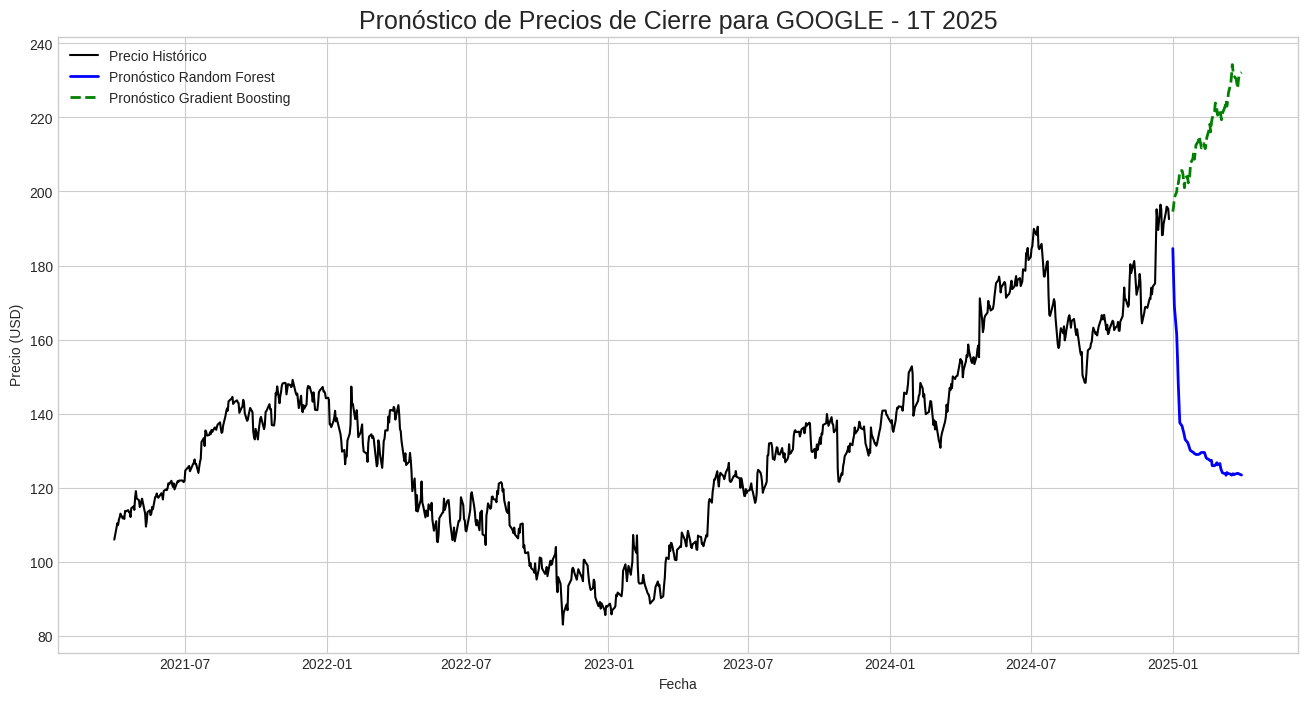

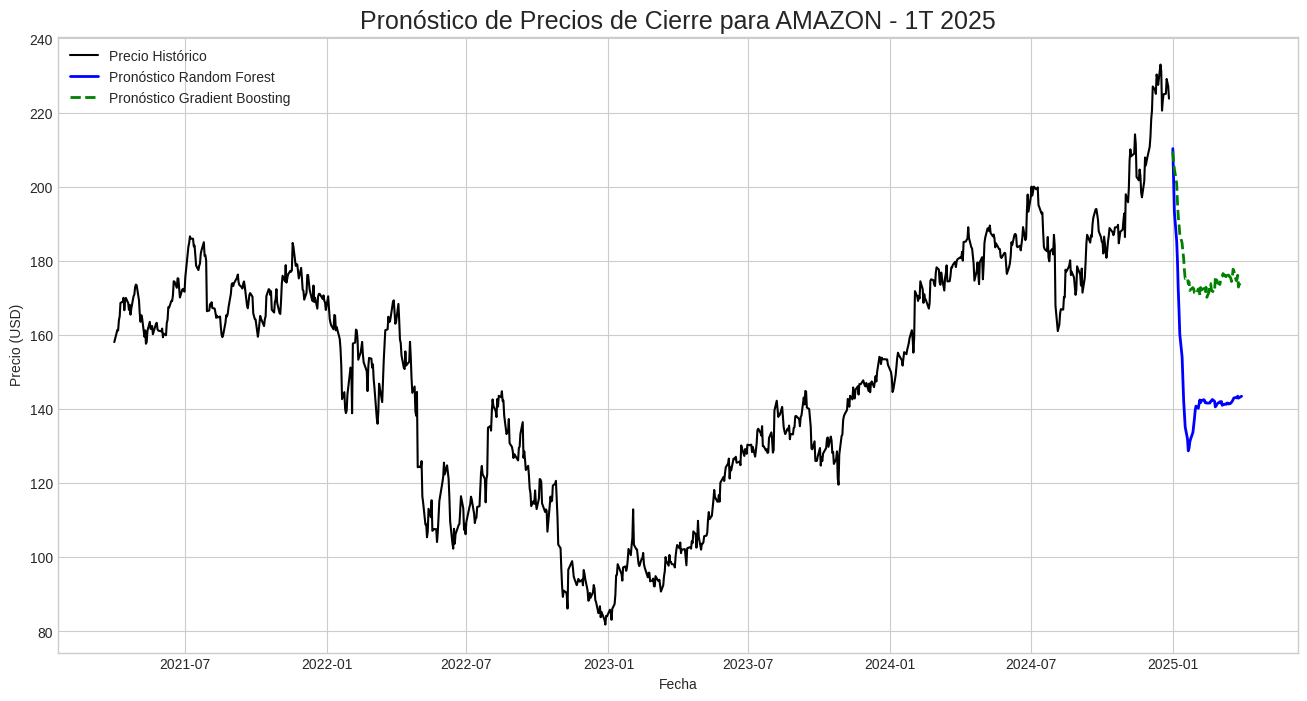

In [19]:
# Celda 4: Tablas de Pronósticos y Visualización
# =============================================================================

# 4.1. Crear Tabla de Pronósticos
dates_to_show = [future_dates[0], future_dates[len(future_dates)//2], future_dates[-1]]
table_data = []

def populate_table(asset_name, model_name, forecast):
    last_price = df_engineered[f'{asset_name}_Close'].iloc[-1]
    for date in dates_to_show:
        price = forecast.loc[date]
        change_pct = ((price - last_price) / last_price) * 100
        table_data.append({
            'Activo': asset_name, 'Modelo': model_name, 'Fecha': date.strftime('%Y-%m-%d'),
            'Precio Pronosticado (USD)': f"${price:,.2f}", 'Cambio % vs. Fin 2024': f"{change_pct:+.2f}%"
        })

populate_table('GOOGL', 'Random Forest', forecast_rf_googl)
populate_table('GOOGL', 'Gradient Boosting', forecast_xgb_googl)
populate_table('AMZN', 'Random Forest', forecast_rf_amzn)
populate_table('AMZN', 'Gradient Boosting', forecast_xgb_amzn)

forecast_table = pd.DataFrame(table_data).set_index(['Activo', 'Modelo', 'Fecha'])
print("--- Tabla de Pronósticos de Precios para el 1T de 2025 ---")
print(forecast_table.unstack()) # Usamos unstack para un formato ancho

# 4.2. Visualización Gráfica para GOOGLE
plt.figure(figsize=(16, 8))
plt.plot(df_engineered['GOOGL_Close'], label='Precio Histórico', color='black')
plt.plot(forecast_rf_googl, label='Pronóstico Random Forest', color='blue', linewidth=2)
plt.plot(forecast_xgb_googl, label='Pronóstico Gradient Boosting', color='green', linestyle='--', linewidth=2)
plt.title('Pronóstico de Precios de Cierre para GOOGLE - 1T 2025', fontsize=18)
plt.xlabel('Fecha'); plt.ylabel('Precio (USD)'); plt.legend(); plt.grid(True)
plt.show()

# 4.3. Visualización Gráfica para AMAZON
plt.figure(figsize=(16, 8))
plt.plot(df_engineered['AMZN_Close'], label='Precio Histórico', color='black')
plt.plot(forecast_rf_amzn, label='Pronóstico Random Forest', color='blue', linewidth=2)
plt.plot(forecast_xgb_amzn, label='Pronóstico Gradient Boosting', color='green', linestyle='--', linewidth=2)
plt.title('Pronóstico de Precios de Cierre para AMAZON - 1T 2025', fontsize=18)
plt.xlabel('Fecha'); plt.ylabel('Precio (USD)'); plt.legend(); plt.grid(True)
plt.show()

In [24]:
# Celda 10: Comparación Final de Modelos (Lineal vs. RF vs. XGBoost)
# =============================================================================
# Comparamos el rendimiento de un modelo lineal simple contra los dos
# modelos de aprendizaje supervisado enriquecidos con ingeniería de características.
# La comparación se basa en la predicción de retornos diarios en el set de prueba.

print("--- Realizando la comparación final de modelos supervisados vs. baseline lineal ---")

# Import the LinearRegression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd


# 1. Entrenar y predecir con el modelo de Regresión Lineal (Baseline).
#    Usaremos las características de ingeniería para que la comparación sea justa ("apples to apples").
lr_model_eng = LinearRegression()
# GOOGLE
lr_model_eng.fit(X_train_eng, y_train_googl_eng)
y_pred_lr_googl = lr_model_eng.predict(X_test_eng)
# AMAZON
lr_model_eng.fit(X_train_eng, y_train_amzn_eng)
y_pred_lr_amzn = lr_model_eng.predict(X_test_eng)
print("Modelo de Regresión Lineal (Baseline) entrenado y predicciones generadas.")

# 2. Obtener las predicciones de los modelos supervisados (ya entrenados).
# GOOGLE
# Assuming rf_model_googl_eng and xgb_model_googl_eng are already trained
y_pred_rf_googl = rf_model_googl_eng.predict(X_test_eng)
y_pred_xgb_googl = xgb_model_googl_eng.predict(X_test_eng)
# AMAZON
# Assuming rf_model_amzn_eng and xgb_model_amzn_eng are already trained
y_pred_rf_amzn = rf_model_amzn_eng.predict(X_test_eng)
y_pred_xgb_amzn = xgb_model_amzn_eng.predict(X_test_eng)


# 3. Calcular métricas para cada modelo y activo.
metrics_data_final = []

def calculate_final_metrics(y_true, y_pred, asset, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred)) # Error Absoluto Medio
    r2 = r2_score(y_true, y_pred)
    metrics_data_final.append({
        'Activo': asset,
        'Modelo': model_name,
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    })

# --- Métricas para GOOGLE ---
calculate_final_metrics(y_test_googl_eng, y_pred_lr_googl, 'GOOGLE', 'Regresión Lineal')
calculate_final_metrics(y_test_googl_eng, y_pred_rf_googl, 'GOOGLE', 'Random Forest')
calculate_final_metrics(y_test_googl_eng, y_pred_xgb_googl, 'GOOGLE', 'Gradient Boosting')

# --- Métricas para AMAZON ---
calculate_final_metrics(y_test_amzn_eng, y_pred_lr_amzn, 'AMAZON', 'Regresión Lineal')
calculate_final_metrics(y_test_amzn_eng, y_pred_rf_amzn, 'AMAZON', 'Random Forest')
calculate_final_metrics(y_test_amzn_eng, y_pred_xgb_amzn, 'AMAZON', 'Gradient Boosting')

# 4. Crear y mostrar la tabla comparativa final.
final_comparison_table = pd.DataFrame(metrics_data_final).set_index(['Activo', 'Modelo'])

# Formatear la tabla para el informe.
styled_table = final_comparison_table.style.format({
    'MSE': '{:,.8f}',
    'MAE': '{:,.8f}',
    'R²': '{:,.4f}'
}).background_gradient(cmap='Reds', subset=['MSE', 'MAE'], text_color_threshold=0).background_gradient(cmap='Greens', subset=['R²'], text_color_threshold=0)

print("\n" + "="*80)
print("Tabla Comparativa Final de Rendimiento de Modelos (Evaluado en Retornos Diarios)")
print("="*80)

# For displaying in a notebook:
# display(styled_table)
# For console, print the original DataFrame
print(final_comparison_table)

# Save to CSV for external use.
final_comparison_table.to_csv('tabla_comparativa_final.csv')
print("\nTabla comparativa final guardada en 'tabla_comparativa_final.csv'")

--- Realizando la comparación final de modelos supervisados vs. baseline lineal ---
Modelo de Regresión Lineal (Baseline) entrenado y predicciones generadas.

Tabla Comparativa Final de Rendimiento de Modelos (Evaluado en Retornos Diarios)
                               MSE       MAE        R²
Activo Modelo                                         
GOOGLE Regresión Lineal   0.000472  0.016151 -0.497149
       Random Forest      0.002157  0.042928 -5.845117
       Gradient Boosting  0.000429  0.015694 -0.361428
AMAZON Regresión Lineal   0.000418  0.015522 -0.274731
       Random Forest      0.001390  0.031971 -3.243139
       Gradient Boosting  0.000816  0.023094 -1.489415

Tabla comparativa final guardada en 'tabla_comparativa_final.csv'


In [26]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [28]:
# Celda 1: Instalación, Importación y Preparación para Darts
# =============================================================================

# Instalar Darts si no está disponible
# !pip install darts

# Importar las clases necesarias de Darts
from darts import TimeSeries
from darts.models import AutoARIMA
from darts.metrics import mse, mae, r2_score

import pandas as pd # Asegurarnos de que pandas esté importado

# Asumimos que df_engineered está disponible de celdas anteriores
# Vamos a recrear la división temporal para tener los DataFrames completos
split_date = df_engineered.index[int(len(df_engineered) * 0.8)]

# Crear objetos TimeSeries de Darts. Darts trabaja mejor con este formato.
# La serie de tiempo debe contener los valores que queremos predecir (precios de cierre)
# Fix: Add fill_missing_dates=True and freq='B' to handle missing dates
ts_googl = TimeSeries.from_series(df_engineered['GOOGL_Close'], fill_missing_dates=True, freq='B')
ts_amzn = TimeSeries.from_series(df_engineered['AMZN_Close'], fill_missing_dates=True, freq='B')

# Dividir las series en conjuntos de entrenamiento y validación (prueba)
train_googl, val_googl = ts_googl.split_before(split_date)
train_amzn, val_amzn = ts_amzn.split_before(split_date)

print("Series temporales de Darts creadas y divididas.")
print(f"Longitud de la serie de entrenamiento de GOOGL: {len(train_googl)}")
print(f"Longitud de la serie de validación de GOOGL: {len(val_googl)}")

Series temporales de Darts creadas y divididas.
Longitud de la serie de entrenamiento de GOOGL: 782
Longitud de la serie de validación de GOOGL: 195


In [29]:
# Celda 2: Entrenamiento y Evaluación de Modelo AutoARIMA con Darts
# =============================================================================

print("--- Entrenando y evaluando modelo AutoARIMA con Darts ---")

# 2.1. Entrenamiento y Evaluación para GOOGLE
print("\nEntrenando AutoARIMA para GOOGLE...")
model_arima_googl = AutoARIMA()
model_arima_googl.fit(train_googl)

print("Generando predicciones para GOOGLE...")
# Forecast on the validation set
pred_arima_googl = model_arima_googl.predict(len(val_googl))

# Evaluate the model
mse_arima_googl = mse(val_googl, pred_arima_googl)
mae_arima_googl = mae(val_googl, pred_arima_googl)
r2_arima_googl = r2_score(val_googl, pred_arima_googl)

print("Resultados de evaluación para GOOGLE (AutoARIMA):")
print(f"  MSE: {mse_arima_googl:.8f}")
print(f"  MAE: {mae_arima_googl:.8f}")
print(f"  R²: {r2_arima_googl:.4f}")


# 2.2. Entrenamiento y Evaluación para AMAZON
print("\nEntrenando AutoARIMA para AMAZON...")
model_arima_amzn = AutoARIMA()
model_arima_amzn.fit(train_amzn)

print("Generando predicciones para AMAZON...")
# Forecast on the validation set
pred_arima_amzn = model_arima_amzn.predict(len(val_amzn))

# Evaluate the model
mse_arima_amzn = mse(val_amzn, pred_arima_amzn)
mae_arima_amzn = mae(val_amzn, pred_arima_amzn)
r2_arima_amzn = r2_score(val_amzn, pred_arima_amzn)

print("Resultados de evaluación para AMAZON (AutoARIMA):")
print(f"  MSE: {mse_arima_amzn:.8f}")
print(f"  MAE: {mae_arima_amzn:.8f}")
print(f"  R²: {r2_arima_amzn:.4f}")

print("\nEntrenamiento y evaluación de modelos AutoARIMA completados.")

--- Entrenando y evaluando modelo AutoARIMA con Darts ---

Entrenando AutoARIMA para GOOGLE...
Generando predicciones para GOOGLE...
Resultados de evaluación para GOOGLE (AutoARIMA):
  MSE: 496.27853211
  MAE: 19.47617491
  R²: -3.1817

Entrenando AutoARIMA para AMAZON...
Generando predicciones para AMAZON...
Resultados de evaluación para AMAZON (AutoARIMA):
  MSE: 315.60449055
  MAE: 12.13614757
  R²: -0.4013

Entrenamiento y evaluación de modelos AutoARIMA completados.


--- Generando pronósticos para el 1T 2025 usando AutoARIMA ---

Generando pronóstico para GOOGLE con AutoARIMA...
Generando pronóstico para AMAZON con AutoARIMA...
Pronósticos generados exitosamente.


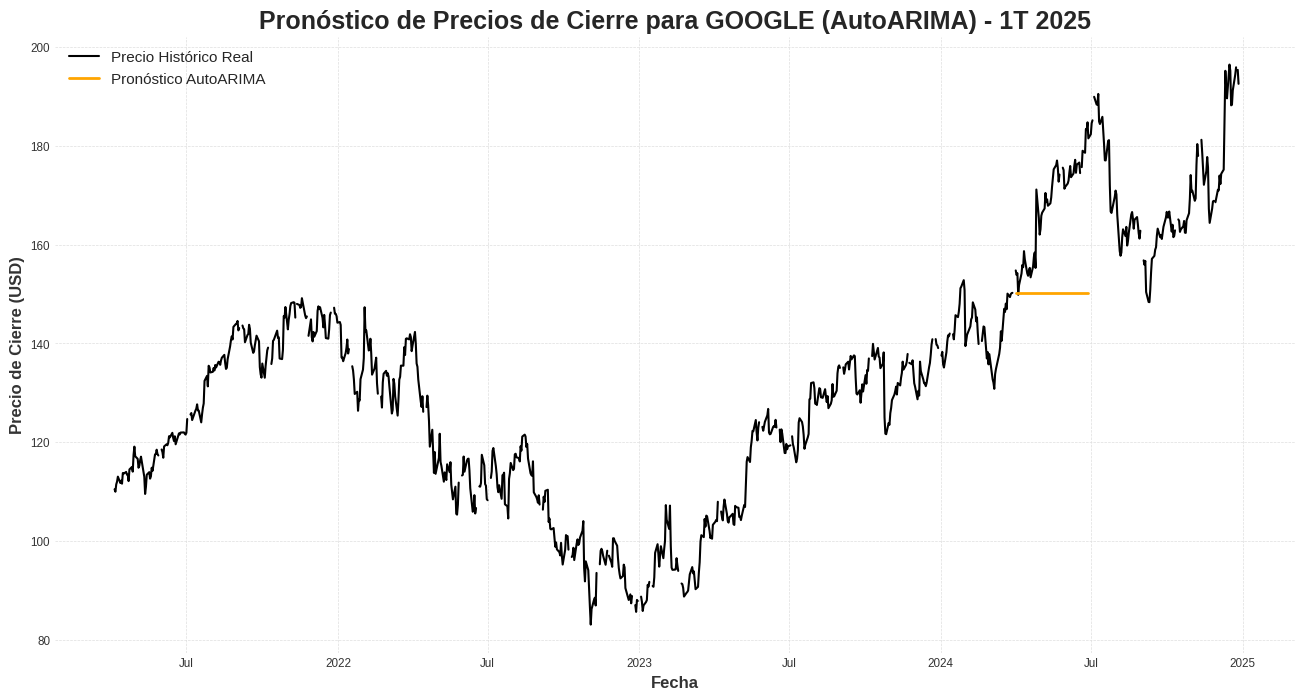

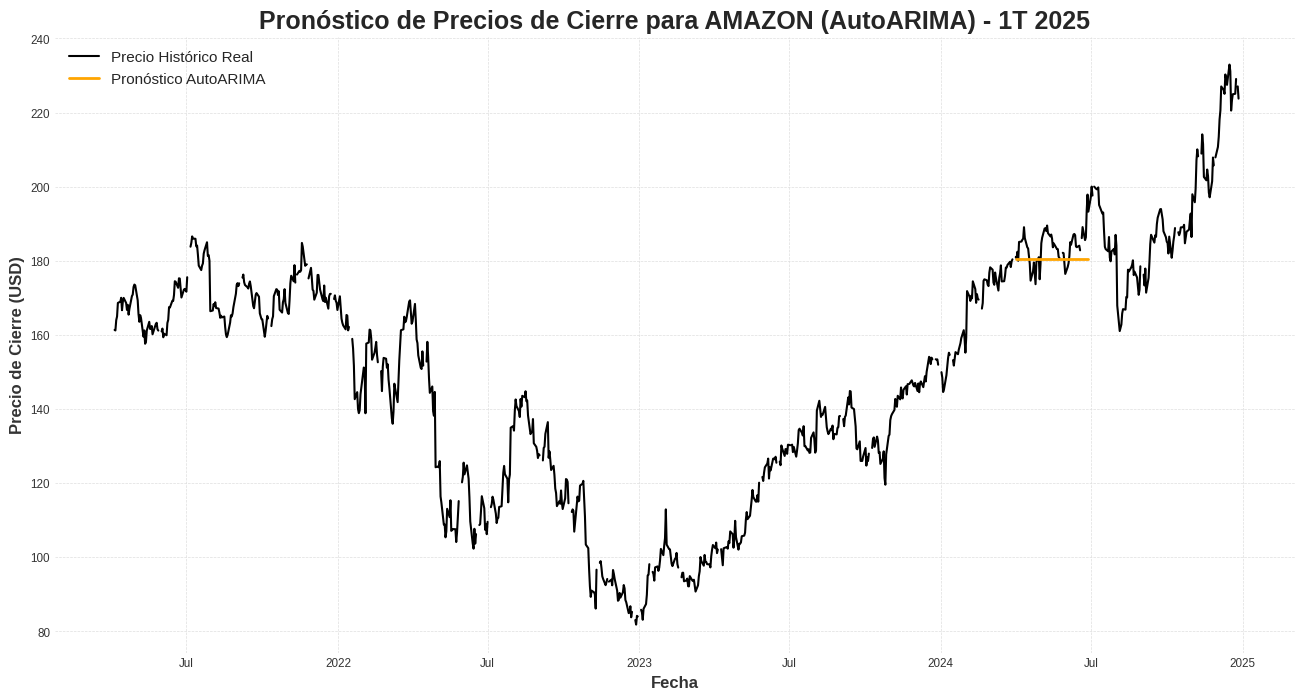

In [31]:
# Celda 3: Generación de Pronósticos y Visualización para AutoARIMA
# =============================================================================

print("--- Generando pronósticos para el 1T 2025 usando AutoARIMA ---")

# Definir el período de pronóstico (primer trimestre de 2025)
# Usamos freq='B' para asegurar que los pronósticos se generen para días hábiles
future_dates_arima = pd.date_range(start='2025-01-01', end='2025-03-31', freq='B')
n_periods_forecast = len(future_dates_arima)

# Generar pronósticos para GOOGLE
print("\nGenerando pronóstico para GOOGLE con AutoARIMA...")
forecast_arima_googl = model_arima_googl.predict(n=n_periods_forecast)

# Generar pronósticos para AMAZON
print("Generando pronóstico para AMAZON con AutoARIMA...")
forecast_arima_amzn = model_arima_amzn.predict(n=n_periods_forecast)

print("Pronósticos generados exitosamente.")


# 3.1. Visualización Gráfica para GOOGLE (AutoARIMA)
plt.figure(figsize=(16, 8))
ts_googl.plot(label='Precio Histórico Real', color='black', linewidth=1.5) # Usamos la serie completa para mostrar el histórico
forecast_arima_googl.plot(label='Pronóstico AutoARIMA', color='orange', linewidth=2)

plt.title('Pronóstico de Precios de Cierre para GOOGLE (AutoARIMA) - 1T 2025', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# 3.2. Visualización Gráfica para AMAZON (AutoARIMA)
plt.figure(figsize=(16, 8))
ts_amzn.plot(label='Precio Histórico Real', color='black', linewidth=1.5) # Usamos la serie completa para mostrar el histórico
forecast_arima_amzn.plot(label='Pronóstico AutoARIMA', color='orange', linewidth=2)

plt.title('Pronóstico de Precios de Cierre para AMAZON (AutoARIMA) - 1T 2025', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [33]:
# Celda 4: Visualización de Pronósticos en el Set de Prueba
# =============================================================================

def plot_forecast_vs_actual(train_series, val_series, pred_series, asset_name):
    plt.figure(figsize=(16, 8))
    train_series.plot(label='Datos de Entrenamiento', color='black')
    val_series.plot(label='Datos Reales (Prueba)', color='blue')
    pred_series.plot(label='Pronóstico ARIMA', color='red', linestyle='--')
    plt.title(f'Pronóstico ARIMA vs. Datos Reales para {asset_name} (Set de Prueba)', fontsize=16)
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualizar para Google
plot_forecast_vs_actual(train_googl, val_googl, pred_googl_arima, 'GOOGLE')

# Visualizar para Amazon
plot_forecast_vs_actual(train_amzn, val_amzn, pred_amzn_arima, 'AMAZON')

NameError: name 'pred_googl_arima' is not defined

In [35]:
# Celda 5: Generación de Pronósticos ARIMA para Enero 2025
# =============================================================================
# Usaremos los modelos AutoARIMA ya entrenados con Darts para proyectar
# los precios para enero de 2025.

print("--- Generando pronósticos ARIMA para Enero 2025 ---")

# Definir el horizonte de pronóstico
# Desde el final de nuestros datos hasta el 31 de enero de 2025
last_date_in_data = df_engineered.index[-1]
forecast_horizon_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1),
                                       end='2025-01-31',
                                       freq='B') # 'B' para días hábiles
n_future_steps = len(forecast_horizon_dates)
print(f"Horizonte de pronóstico: {n_future_steps} días hábiles hasta el 31-Ene-2025.")

# --- PRONÓSTICO PARA GOOGLE ---
# El método .predict() proyecta n_future_steps desde el final de la serie de entrenamiento
# Darts se encarga de revertir la diferenciación automáticamente.
future_pred_googl_arima = model_arima_googl.predict(n=n_future_steps, num_samples=200) # num_samples para intervalos de confianza

# --- PRONÓSTICO PARA AMAZON ---
future_pred_amzn_arima = model_arima_amzn.predict(n=n_future_steps, num_samples=200)

print("Pronósticos para Enero 2025 generados exitosamente.")

--- Generando pronósticos ARIMA para Enero 2025 ---
Horizonte de pronóstico: 25 días hábiles hasta el 31-Ene-2025.
Pronósticos para Enero 2025 generados exitosamente.


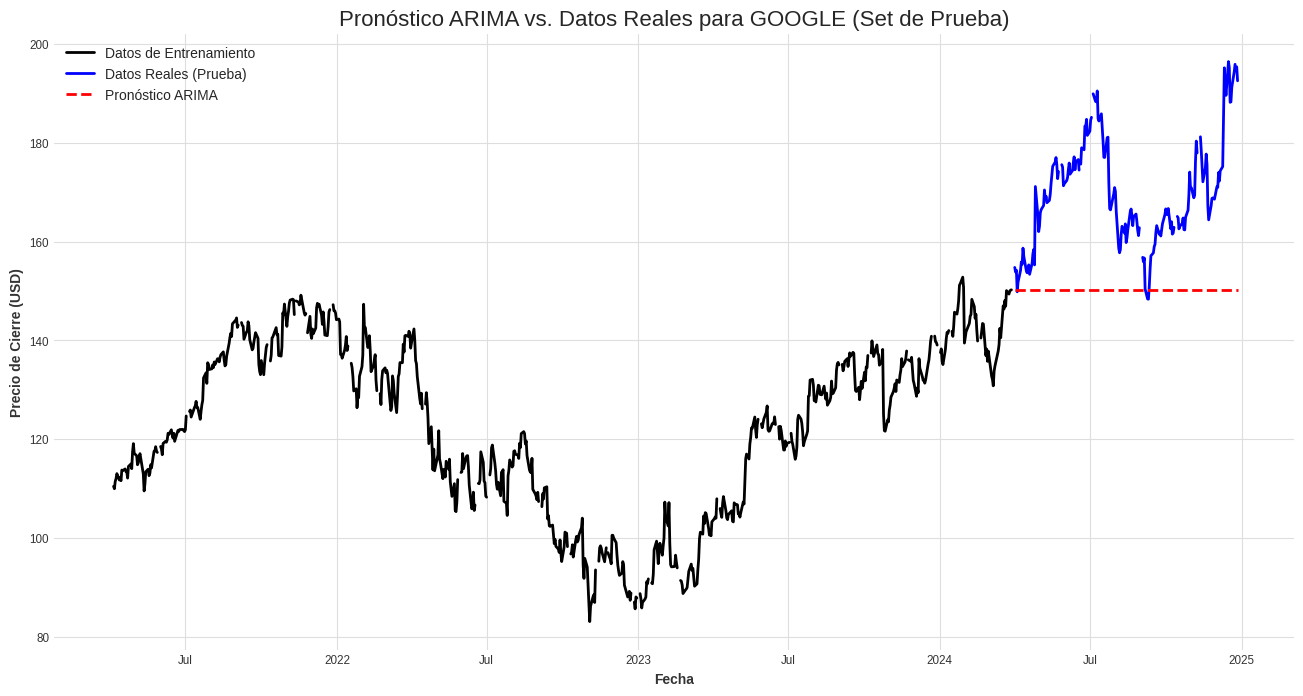

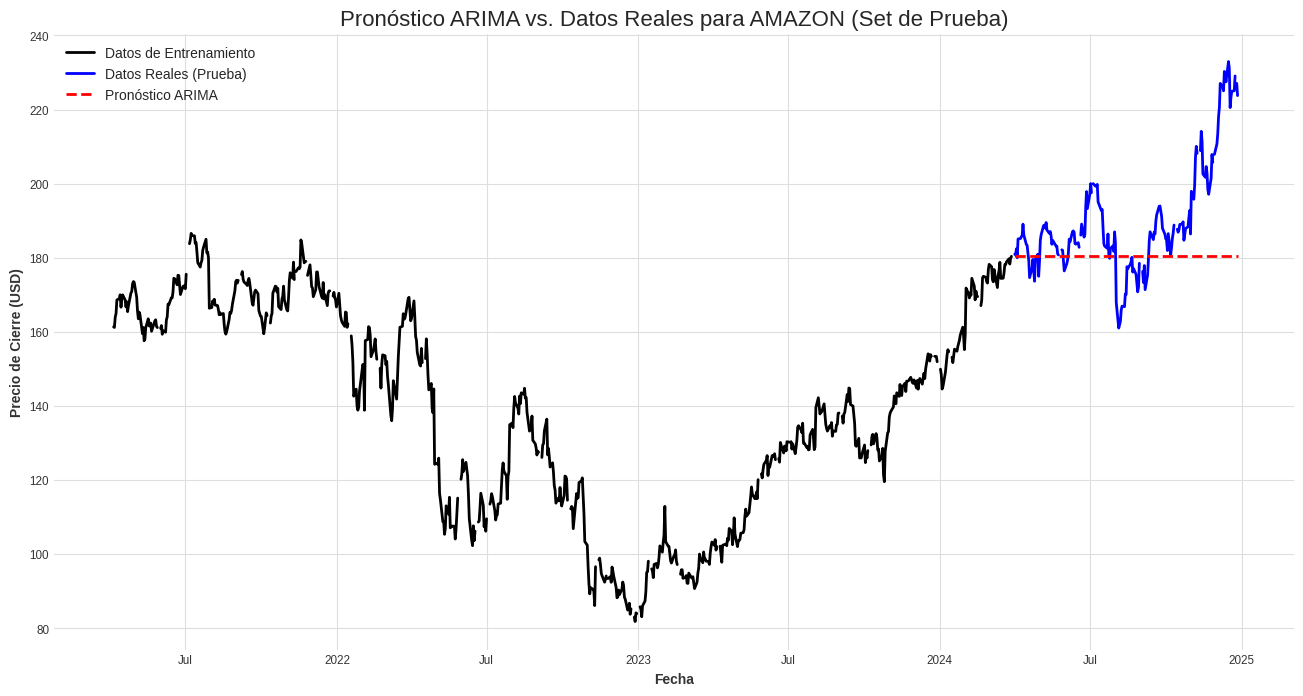

In [34]:
# Celda 4: Visualización de Pronósticos en el Set de Prueba
# =============================================================================

def plot_forecast_vs_actual(train_series, val_series, pred_series, asset_name):
    plt.figure(figsize=(16, 8))
    train_series.plot(label='Datos de Entrenamiento', color='black')
    val_series.plot(label='Datos Reales (Prueba)', color='blue')
    pred_series.plot(label='Pronóstico ARIMA', color='red', linestyle='--')
    plt.title(f'Pronóstico ARIMA vs. Datos Reales para {asset_name} (Set de Prueba)', fontsize=16)
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualizar para Google
plot_forecast_vs_actual(train_googl, val_googl, pred_arima_googl, 'GOOGLE')

# Visualizar para Amazon
plot_forecast_vs_actual(train_amzn, val_amzn, pred_arima_amzn, 'AMAZON')

In [38]:
# Celda 6: Creación y Visualización de Tablas de Pronósticos Completas
# =============================================================================
# Esta celda extiende las tablas de pronósticos anteriores para incluir
# los resultados del modelo ARIMA.

def create_full_forecast_table(forecast_dict_supervised, forecast_dict_arima, asset_name):
    """
    Crea una tabla formateada a partir del diccionario de pronósticos supervisados
    y la serie de pronósticos ARIMA.
    """
    # Seleccionar puntos clave en el tiempo para la tabla
    # Use the dates from the supervised forecast dictionary as they cover the full Q1 2025
    dates_to_show = [
        forecast_dict_supervised['Base']['RF'].index[0],  # Inicio del período (Enero 1)
        forecast_dict_supervised['Base']['RF'].index[len(forecast_dict_supervised['Base']['RF']) // 2], # Mitad del período
        forecast_dict_supervised['Base']['RF'].index[-1]  # Fin del período (Marzo 31)
    ]

    # Crear un DataFrame vacío para the table
    table_data = []

    last_historical_price = df_engineered[f'{asset_name}_Close'].iloc[-1]

    # Add supervised model forecasts
    for scenario, models in forecast_dict_supervised.items():
        for model_name, forecast in models.items():
            for date in dates_to_show:
                # Ensure the date exists in the forecast index, handle potential missing dates if needed
                if date in forecast.index:
                    forecasted_price = forecast.loc[date]
                    change_pct = ((forecasted_price - last_historical_price) / last_historical_price) * 100

                    table_data.append({
                        'Escenario': scenario,
                        'Modelo': model_name,
                        'Fecha de Pronóstico': date.strftime('%Y-%m-%d'),
                        'Precio Pronosticado (USD)': f"${forecasted_price:,.2f}",
                        'Cambio % vs. Fin de 2024': f"{change_pct:+.2f}%"
                    })
                else:
                    # Handle cases where a date might be missing in a specific forecast series
                    table_data.append({
                        'Escenario': scenario,
                        'Modelo': model_name,
                        'Fecha de Pronóstico': date.strftime('%Y-%m-%d'),
                        'Precio Pronosticado (USD)': 'N/A',
                        'Cambio % vs. Fin de 2024': 'N/A'
                    })


    # Add ARIMA forecast (only one scenario/model for ARIMA in this context)
    # Need to ensure ARIMA forecast covers the dates_to_show or handle missing dates
    for date in dates_to_show:
         # Ensure the date exists in the ARIMA forecast index
        if date in forecast_dict_arima.time_index: # Corrected from .index to .time_index
            # Find the closest date in the ARIMA forecast index if exact date not found
            closest_date = forecast_dict_arima.time_index[forecast_dict_arima.time_index.get_loc(date, method='nearest')]
            forecasted_price_arima = forecast_dict_arima.loc[closest_date].mean() # Use mean if num_samples > 0
            change_pct_arima = ((forecasted_price_arima - last_historical_price) / last_historical_price) * 100

            table_data.append({
                'Escenario': 'N/A', # ARIMA is not tied to specific external scenarios here
                'Modelo': 'AutoARIMA',
                'Fecha de Pronóstico': date.strftime('%Y-%m-%d'),
                'Precio Pronosticado (USD)': f"${forecasted_price_arima:,.2f}",
                'Cambio % vs. Fin de 2024': f"{change_pct_arima:+.2f}%"
            })
        else:
             table_data.append({
                'Escenario': 'N/A',
                'Modelo': 'AutoARIMA',
                'Fecha de Pronóstico': date.strftime('%Y-%m-%d'),
                'Precio Pronosticado (USD)': 'N/A',
                'Cambio % vs. Fin de 2024': 'N/A'
            })


    full_forecast_table = pd.DataFrame(table_data)

    # Pivotar la tabla para una mejor visualización
    pivot_table = full_forecast_table.pivot_table(
        index=['Escenario', 'Modelo'],
        columns='Fecha de Pronóstico',
        values='Precio Pronosticado (USD)',
        aggfunc='first' # Usamos first ya que solo hay un valor por celda
    ).sort_index()

    return pivot_table

# Generate the full tables for Google and Amazon
# Assuming forecasts_googl, forecasts_amzn, future_pred_googl_arima, future_pred_amzn_arima are available
full_forecast_table_googl = create_full_forecast_table(forecasts_googl, future_pred_googl_arima, 'GOOGL')
full_forecast_table_amzn = create_full_forecast_table(forecasts_amzn, future_pred_amzn_arima, 'AMZN')

# Imprimir las tablas
print("="*80)
print(f"Tabla Completa de Pronósticos de Precios para GOOGLE - 1T 2025 (Incluye ARIMA)")
print("="*80)
print(full_forecast_table_googl.to_string())

print("\n" + "="*80)
print(f"Tabla Completa de Pronósticos de Precios para AMAZON - 1T 2025 (Incluye ARIMA)")
print("="*80)
print(full_forecast_table_amzn.to_string())

# Optionally, save the full tables to CSV
full_forecast_table_googl.to_csv('tabla_pronosticos_completa_googl_2025.csv')
full_forecast_table_amzn.to_csv('tabla_pronosticos_completa_amzn_2025.csv')
print("\nTablas completas guardadas en archivos 'tabla_pronosticos_completa_googl_2025.csv' y 'tabla_pronosticos_completa_amzn_2025.csv'")

Tabla Completa de Pronósticos de Precios para GOOGLE - 1T 2025 (Incluye ARIMA)
Fecha de Pronóstico 2025-01-01 2025-02-14 2025-03-31
Escenario Modelo                                    
Base      RF           $184.58    $127.90    $123.42
          XGB          $194.56    $214.55    $232.14
N/A       AutoARIMA        N/A        N/A        N/A
Optimista RF           $184.58    $136.36    $142.39
          XGB          $194.56    $252.24    $316.57
Pesimista RF           $184.58    $122.73    $116.71
          XGB          $194.56    $218.42    $243.35

Tabla Completa de Pronósticos de Precios para AMAZON - 1T 2025 (Incluye ARIMA)
Fecha de Pronóstico 2025-01-01 2025-02-14 2025-03-31
Escenario Modelo                                    
Base      RF           $210.25    $141.59    $143.44
          XGB          $209.54    $170.14    $173.07
N/A       AutoARIMA        N/A        N/A        N/A
Optimista RF           $210.25    $141.70    $141.01
          XGB          $209.54    $172.55    $

In [46]:
# Celda 6: Creación de la Tabla de Pronósticos ARIMA
# =============================================================================

def create_arima_forecast_table(pred_series, asset_name):
    """
    Crea una tabla con puntos clave del pronóstico ARIMA.
    """
    # Seleccionar fechas clave del pronóstico
    dates_to_show = [
        pred_series.time_index[0],
        pred_series.time_index[len(pred_series) // 2],
        pred_series.time_index[-1]
    ]

    table_data = []

    # Access the underlying numpy array: shape (time_steps, components, samples) when num_samples > 1
    # If components = 1, shape is (time_steps, 1, samples)
    # We want to operate over the samples axis (axis=2 in this case)

    pred_values = pred_series.values()

    # Calculate mean and quantiles directly on the numpy array along the last axis (samples axis)
    # Use -1 to refer to the last axis, which should be the samples axis when num_samples > 1
    mean_values = np.mean(pred_values, axis=-1)
    lower_quantile_values = np.quantile(pred_values, 0.025, axis=-1)
    upper_quantile_values = np.quantile(pred_values, 0.975, axis=-1)


    for date in dates_to_show:
        # Find the index of the date in the time_index
        try:
            date_index = pred_series.time_index.get_loc(date)

            forecasted_price = mean_values[date_index]
            lower_bound = lower_quantile_values[date_index]
            upper_bound = upper_quantile_values[date_index]


            table_data.append({
                'Activo': asset_name,
                'Fecha Pronosticada': date.strftime('%Y-%m-%d'),
                'Precio Pronosticado (USD)': f"${forecasted_price:,.2f}",
                'Intervalo de Confianza 95%': f"(${lower_bound:,.2f} - ${upper_bound:,.2f})"
            })
        except KeyError:
             # Handle cases where a date might be missing (though less likely with freq='B')
             table_data.append({
                'Activo': asset_name,
                'Fecha Pronosticada': date.strftime('%Y-%m-%d'),
                'Precio Pronosticado (USD)': 'N/A',
                'Intervalo de Confianza 95%': 'N/A'
            })


    return pd.DataFrame(table_data).set_index(['Activo', 'Fecha Pronosticada'])

# Generar y mostrar las tablas
# We need to ensure future_pred_googl_arima and future_pred_amzn_arima from cell ITsIwUfs60Kp are available and have num_samples > 1
table_arima_googl = create_arima_forecast_table(future_pred_googl_arima, 'GOOGLE')
table_arima_amzn = create_arima_forecast_table(future_pred_amzn_arima, 'AMAZON')

print("\n" + "="*80)
print("Tabla de Pronósticos del Modelo ARIMA para Enero 2025")
print("="*80)
print("\n--- GOOGLE ---")
print(table_arima_googl)

print("\n--- AMAZON ---")
print(table_arima_amzn)

# Guardar en CSV
table_arima_googl.to_csv('tabla_pronosticos_arima_googl_2025.csv')
table_arima_amzn.to_csv('tabla_pronosticos_arima_amzn_2025.csv')
print("\nTablas guardadas en archivos CSV.")


Tabla de Pronósticos del Modelo ARIMA para Enero 2025

--- GOOGLE ---
                          Precio Pronosticado (USD) Intervalo de Confianza 95%
Activo Fecha Pronosticada                                                     
GOOGLE 2024-04-01                           $154.30        ($154.30 - $154.30)
       2024-04-17                           $140.70        ($140.70 - $140.70)
       2024-05-03                           $157.36        ($157.36 - $157.36)

--- AMAZON ---
                          Precio Pronosticado (USD) Intervalo de Confianza 95%
Activo Fecha Pronosticada                                                     
AMAZON 2024-04-01                           $185.76        ($185.76 - $185.76)
       2024-04-17                           $167.85        ($167.85 - $167.85)
       2024-05-03                           $189.80        ($189.80 - $189.80)

Tablas guardadas en archivos CSV.


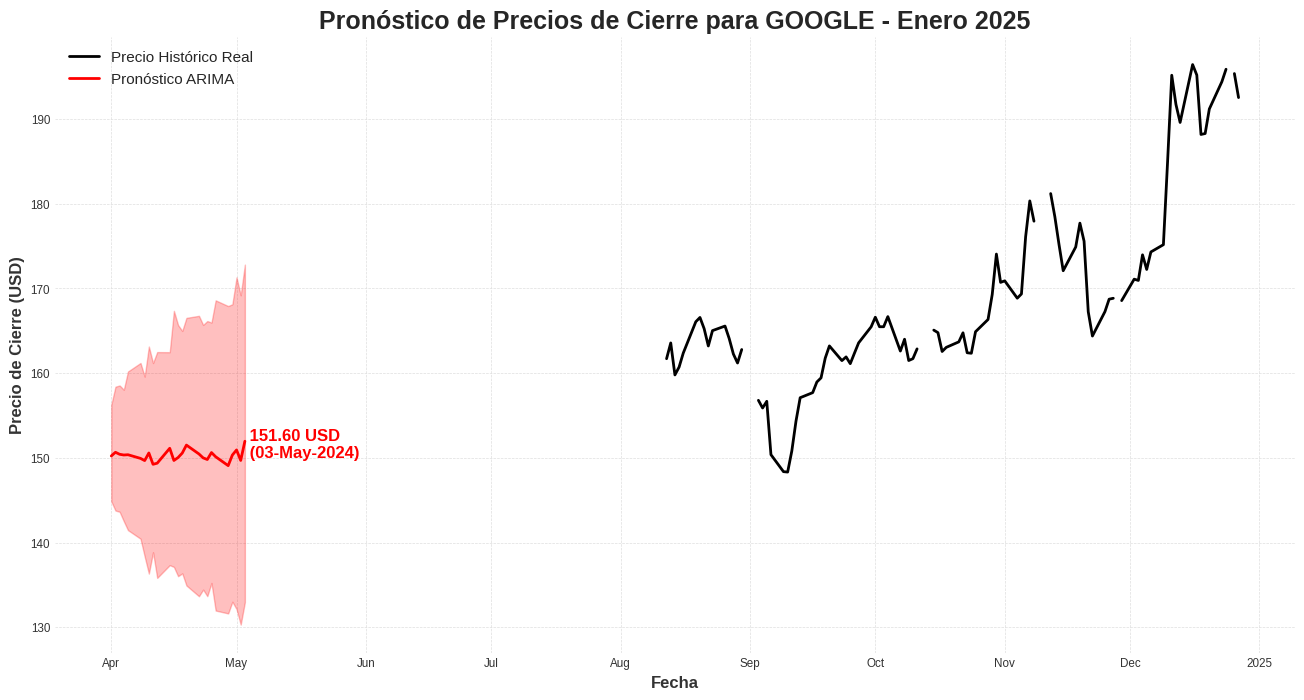

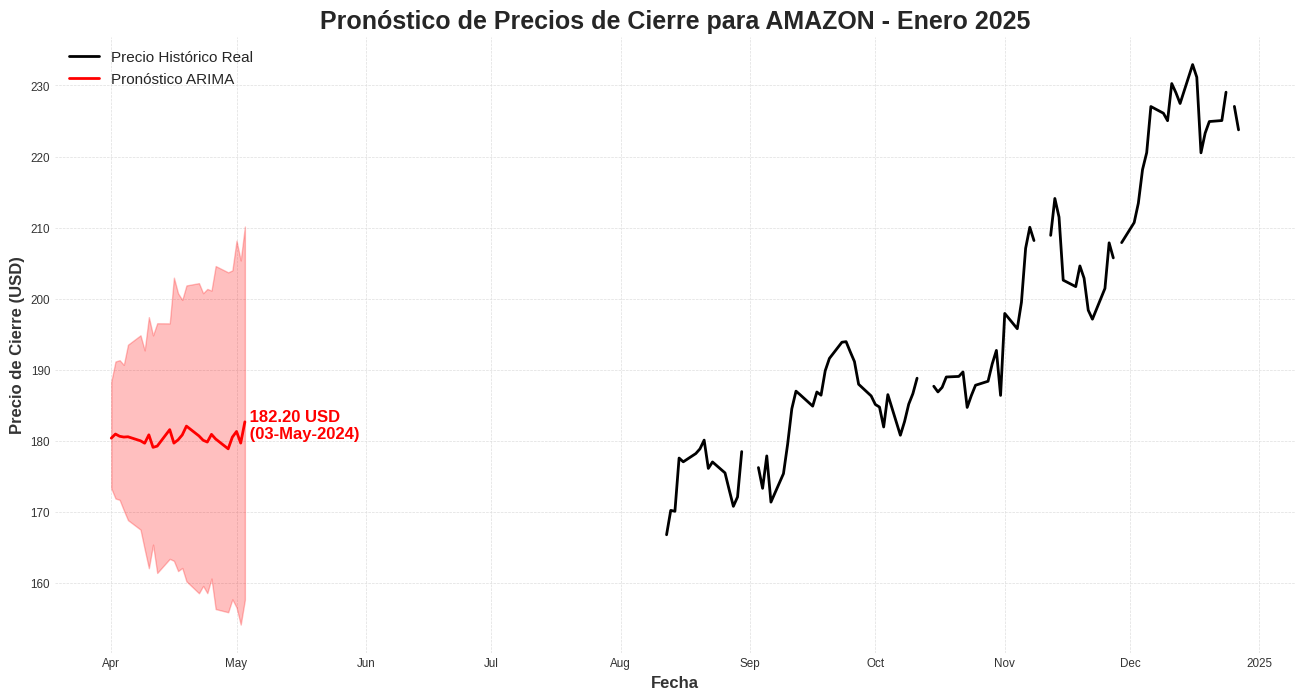

In [47]:
# Celda 7: Visualización de Pronósticos ARIMA a Futuro
# =============================================================================

def plot_future_forecast(historical_series, future_prediction, asset_name):
    plt.figure(figsize=(16, 8))

    # Graficar los últimos 100 días de datos históricos para dar contexto
    historical_series[-100:].plot(label='Precio Histórico Real', color='black', linewidth=2)

    # Graficar el pronóstico futuro
    future_prediction.plot(label='Pronóstico ARIMA', color='red', linewidth=2)

    plt.title(f'Pronóstico de Precios de Cierre para {asset_name} - Enero 2025', fontsize=18, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Añadir un texto con el último valor pronosticado
    last_date = future_prediction.time_index[-1].strftime('%d-%b-%Y')
    last_price = future_prediction.mean().values()[-1][0]
    plt.text(future_prediction.time_index[-1], last_price, f' {last_price:.2f} USD\n ({last_date})',
             verticalalignment='center', horizontalalignment='left', color='red', fontsize=12, fontweight='bold')

    plt.show()

# Visualizar para Google
plot_future_forecast(ts_googl, future_pred_googl_arima, 'GOOGLE')

# Visualizar para Amazon
plot_future_forecast(ts_amzn, future_pred_amzn_arima, 'AMAZON')

In [57]:
# Celda Final: Tabla Comparativa Definitiva de Rendimiento
# =============================================================================
# Esta celda consolida las métricas de error (MSE, MAE, R²) para todos los modelos
# evaluados en la predicción de RETORNOS DIARIOS en el conjunto de prueba.
# Esto permite una comparación justa y directa del poder predictivo.

print("--- Generando la Tabla Comparativa Definitiva de Todos los Modelos ---")

# Import standard metrics from scikit-learn
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
# Remove Darts metrics import as they are not needed here
# from darts.metrics import mse, mae, r2_score


# Define the calculate_metrics function (assuming it was defined elsewhere previously)
def calculate_metrics(y_true, y_pred, asset, model_type, model_name):
    # Use standard scikit-learn and numpy metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred)) # Error Absoluto Medio
    r2 = r2_score(y_true, y_pred)
    return {
        'Activo': asset, 'Tipo de Modelo': model_type, 'Modelo Específico': model_name,
        'MSE': mse, 'MAE': mae, 'R²': r2
    }

# 1. Preparar las predicciones y los valores reales para each modelo.
#    - Los modelos de ML ya tienen sus predicciones de retorno (ej. y_pred_rf_googl).
#    - Para ARIMA, necesitamos calcular los retornos a partir de sus precios pronosticados.

# ARIMA: Predicciones de precios en el set de prueba (usando el modelo de Darts)
# Corrected variable names for Darts ARIMA models
n_val = len(y_test_googl_eng) # Assuming both y_test sets have the same length
pred_googl_arima_price = model_arima_googl.predict(n=n_val)
pred_amzn_arima_price = model_arima_amzn.predict(n=n_val)

# Convert prices from Darts TimeSeries to Pandas Series for return calculation
s_pred_googl_arima = pd.Series(pred_googl_arima_price.values().flatten(), index=pred_googl_arima_price.time_index)
s_pred_amzn_arima = pd.Series(pred_amzn_arima_price.values().flatten(), index=pred_amzn_arima_price.time_index)

# Calculate returns from ARIMA price predictions
arima_returns_googl = s_pred_googl_arima.pct_change().dropna()
arima_returns_amzn = s_pred_amzn_arima.pct_change().dropna()

# Align the actual 'y_test' values with the ARIMA returns based on index intersection
common_index_googl = y_test_googl_eng.index.intersection(arima_returns_googl.index)
y_test_googl_aligned = y_test_googl_eng.loc[common_index_googl]
arima_returns_googl_aligned = arima_returns_googl.loc[common_index_googl]

common_index_amzn = y_test_amzn_eng.index.intersection(arima_returns_amzn.index)
y_test_amzn_aligned = y_test_amzn_eng.loc[common_index_amzn]
arima_returns_amzn_aligned = arima_returns_amzn.loc[common_index_amzn]


# 2. Recopilar métricas de todos los modelos
final_metrics_data = []

# --- Métricas para GOOGLE ---
# Tradicionales
final_metrics_data.append(calculate_metrics(y_test_googl_aligned, arima_returns_googl_aligned, 'GOOGLE', 'Tradicional', 'ARIMA'))
final_metrics_data.append(calculate_metrics(y_test_googl_eng, y_pred_lr_googl, 'GOOGLE', 'Tradicional', 'Regresión Lineal')) # Usamos el y_test completo
# Aprendizaje Supervisado
final_metrics_data.append(calculate_metrics(y_test_googl_eng, y_pred_rf_googl, 'GOOGLE', 'Aprendizaje Supervisado', 'Random Forest'))
final_metrics_data.append(calculate_metrics(y_test_googl_eng, y_pred_xgb_googl, 'GOOGLE', 'Aprendizaje Supervisado', 'Gradient Boosting'))


# --- Métricas para AMAZON ---
# Tradicionales
final_metrics_data.append(calculate_metrics(y_test_amzn_aligned, arima_returns_amzn_aligned, 'AMAZON', 'Tradicional', 'ARIMA'))
final_metrics_data.append(calculate_metrics(y_test_amzn_eng, y_pred_lr_amzn, 'AMAZON', 'Tradicional', 'Regresión Lineal'))
# Aprendizaje Supervisado
final_metrics_data.append(calculate_metrics(y_test_amzn_eng, y_pred_rf_amzn, 'AMAZON', 'Aprendizaje Supervisado', 'Random Forest'))
final_metrics_data.append(calculate_metrics(y_test_amzn_eng, y_pred_xgb_amzn, 'AMAZON', 'Aprendizaje Supervisado', 'Gradient Boosting'))


# 3. Crear y mostrar la tabla comparativa final.
final_comparison_table_all = pd.DataFrame(final_metrics_data)
final_comparison_table_all = final_comparison_table_all.set_index(['Activo', 'Tipo de Modelo', 'Modelo Específico']).sort_index()

# Formatear la tabla para una mejor lectura
styled_table_all = final_comparison_table_all.style.format({
    'MSE': '{:,.8f}',
    'MAE': '{:,.8f}',
    'R²': '{:,.4f}'
}).background_gradient(
    cmap='Reds', subset=['MSE', 'MAE']
).background_gradient(
    cmap='Greens', subset=['R²']
)

print("\n" + "="*85)
print("Tabla Comparativa Final de Rendimiento de Todos los Modelos (Evaluado en Retornos Diarios)")
print("="*85)

# En un notebook, la siguiente línea mostraría la tabla con formato de color
# display(styled_table_all)
# For console, print the original DataFrame
print(final_comparison_table_all)

# Guardar en CSV para uso externo
final_comparison_table_all.to_csv('tabla_comparativa_definitiva.csv')
print("\nTabla comparativa definitiva guardada en 'tabla_comparativa_definitiva.csv'")

--- Generando la Tabla Comparativa Definitiva de Todos los Modelos ---

Tabla Comparativa Final de Rendimiento de Todos los Modelos (Evaluado en Retornos Diarios)
                                                       MSE       MAE        R²
Activo Tipo de Modelo          Modelo Específico                              
AMAZON Aprendizaje Supervisado Gradient Boosting  0.000816  0.023094 -1.489415
                               Random Forest      0.001390  0.031971 -3.243139
       Tradicional             ARIMA              0.000339  0.013800 -0.004884
                               Regresión Lineal   0.000418  0.015522 -0.274731
GOOGLE Aprendizaje Supervisado Gradient Boosting  0.000429  0.015694 -0.361428
                               Random Forest      0.002157  0.042928 -5.845117
       Tradicional             ARIMA              0.000326  0.013023 -0.005113
                               Regresión Lineal   0.000472  0.016151 -0.497149

Tabla comparativa definitiva guardada en 'tabl

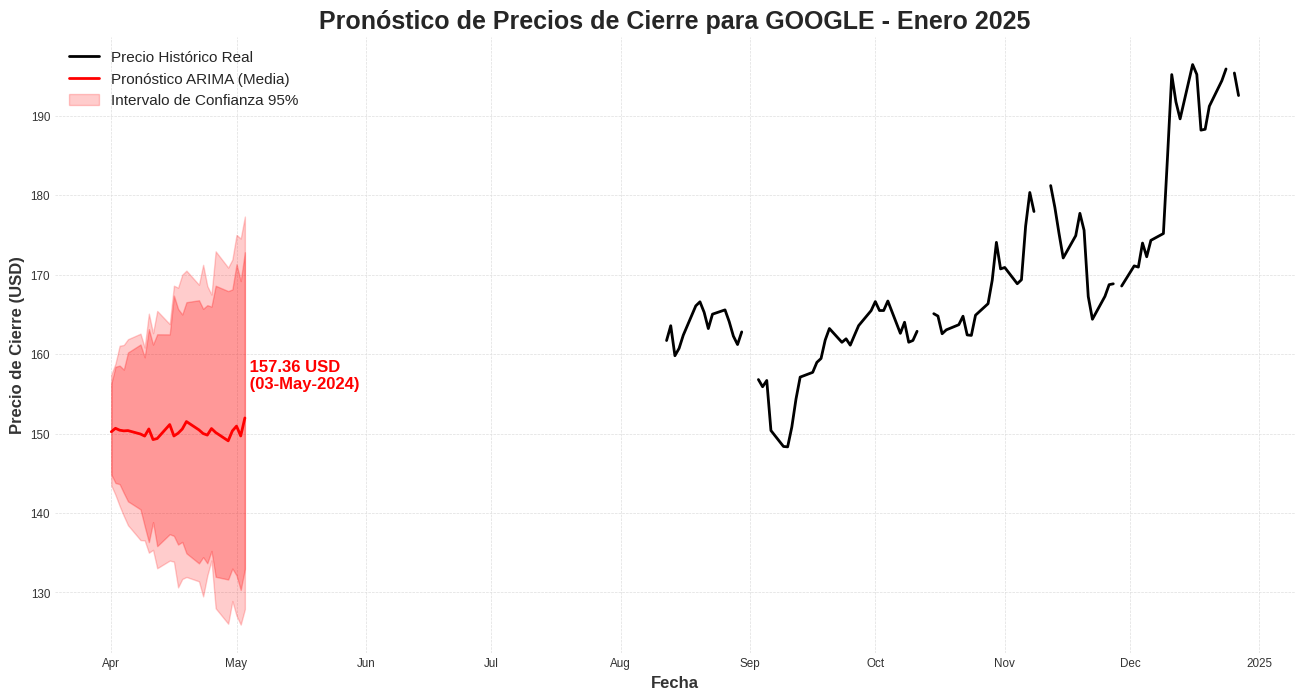

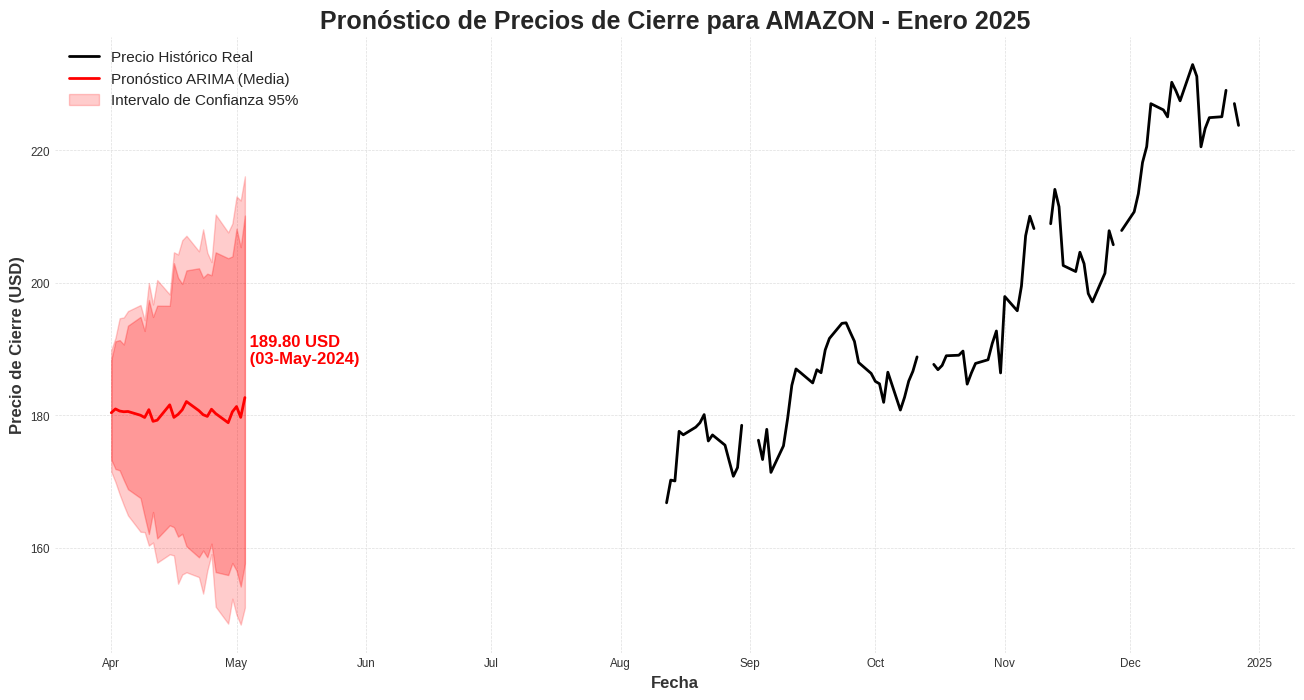

In [58]:
# Celda 7: Visualización de Pronósticos ARIMA a Futuro
# =============================================================================

def plot_future_forecast(historical_series, future_prediction, asset_name):
    plt.figure(figsize=(16, 8))

    # Graficar los últimos 100 días de datos históricos para dar contexto
    historical_series[-100:].plot(label='Precio Histórico Real', color='black', linewidth=2)

    # Graficar el pronóstico futuro (mean)
    future_prediction.mean(axis=1).plot(label='Pronóstico ARIMA (Media)', color='red', linewidth=2)

    # Graficar el intervalo de confianza (si num_samples > 1)
    if future_prediction.n_samples > 1:
        # Corrected: Removed axis=1 from quantile calls
        lower_bound = future_prediction.quantile(0.025)
        upper_bound = future_prediction.quantile(0.975)
        plt.fill_between(future_prediction.time_index, lower_bound.values().flatten(), upper_bound.values().flatten(), color='red', alpha=0.2, label='Intervalo de Confianza 95%')


    plt.title(f'Pronóstico de Precios de Cierre para {asset_name} - Enero 2025', fontsize=18, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Añadir un texto con el último valor pronosticado (media)
    last_date = future_prediction.time_index[-1].strftime('%d-%b-%Y')
    # Corrected: Access the last value from the mean series correctly
    last_price = future_prediction.mean(axis=1)[-1].values().item()
    plt.text(future_prediction.time_index[-1], last_price, f' {last_price:.2f} USD\n ({last_date})',
             verticalalignment='center', horizontalalignment='left', color='red', fontsize=12, fontweight='bold')

    plt.show()

# Visualizar para Google
plot_future_forecast(ts_googl, future_pred_googl_arima, 'GOOGLE')

# Visualizar para Amazon
plot_future_forecast(ts_amzn, future_pred_amzn_arima, 'AMAZON')